In [1]:
import os
dataset_path = "/kaggle/input/datasets/janiherbert/cherry-segmentation-dataset/Cherry Segmentation"
image_dir = dataset_path + "/Original Images"
mask_dir = dataset_path + "/Mask"

0 255
(3000, 3000, 3)
(3000, 3000)
torch.Size([256, 256, 3])
torch.Size([256, 256])
torch.Size([3, 256, 256])


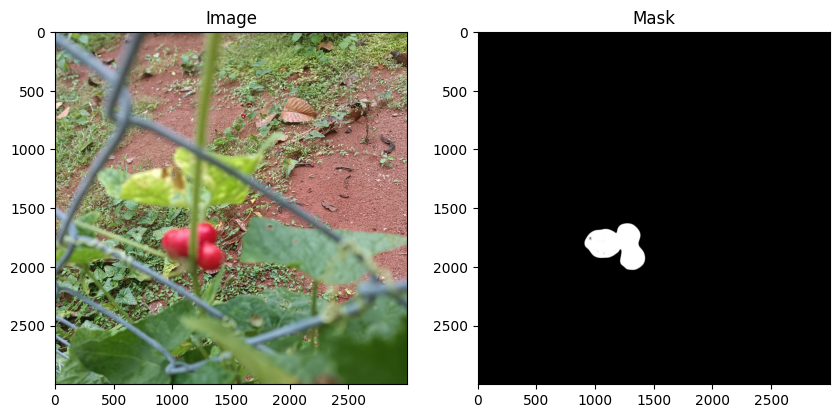

In [2]:
#Visualise One Image And Mask

import cv2
import matplotlib.pyplot as plt

images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

img_path = os.path.join(
    image_dir,
    images[0]
)

mask_path = os.path.join(
    mask_dir,
    masks[0]
)
image = cv2.imread(img_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path,0)

plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask,cmap = "gray")
plt.title("Mask")

#Checking Min And Max Of Mask
print(mask.min(),mask.max())

#Normalise
mask = mask/255.0
image = image/255.0

#Check Size Of Image And Mask

print(image.shape)
print(mask.shape)

#Resize
image = cv2.resize(image,(256,256))
mask = cv2.resize(mask,(256,256))

#Convert To pyTorch

import torch

image = torch.tensor(image).float()
mask = torch.tensor(mask).float()

print(image.shape)
print(mask.shape)

#Rearrange Image Dimensions

image = image.permute(2,0,1)
print(image.shape)

#No need to permute mask since only 2 dimensions

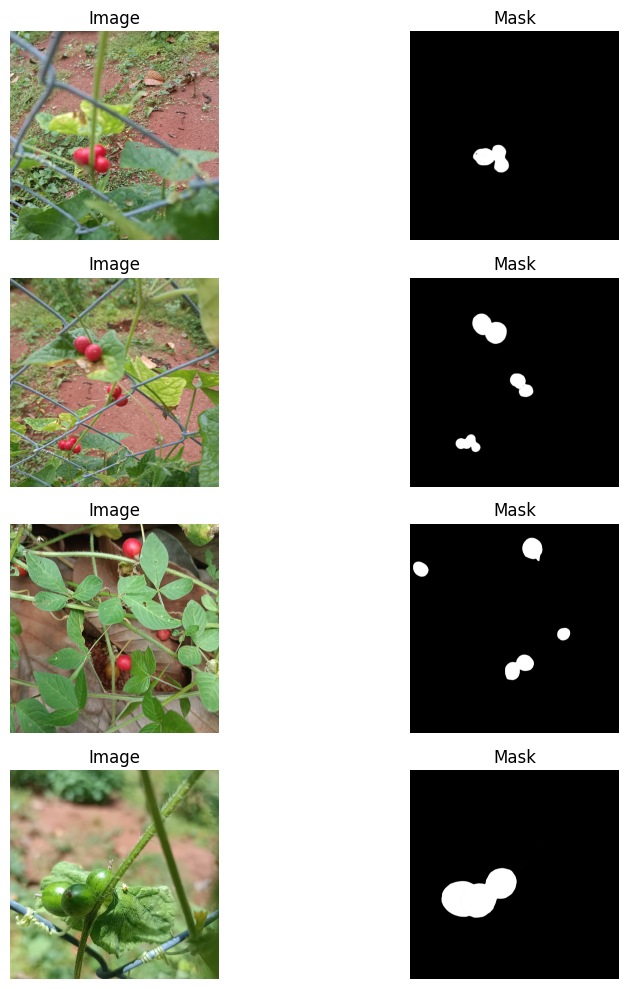

In [3]:
#Visualising Dataset Description

import matplotlib.pyplot as plt

plt.figure(figsize = (10,10))
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))
for i in range(4):
    img_path = os.path.join(image_dir,images[i])
    mask_path = os.path.join(mask_dir,masks[i])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path,0)

    #Plotting Image
    plt.subplot(4,2,i*2 + 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("Off")

    #Plotting Mask
    plt.subplot(4,2,i*2 + 2)
    plt.imshow(mask,cmap = "gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
#Augmentation Pipeline
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p = 0.5),
    A.VerticalFlip(p = 0.5),
    A.Rotate(limit = 30, p = 0.5)
])

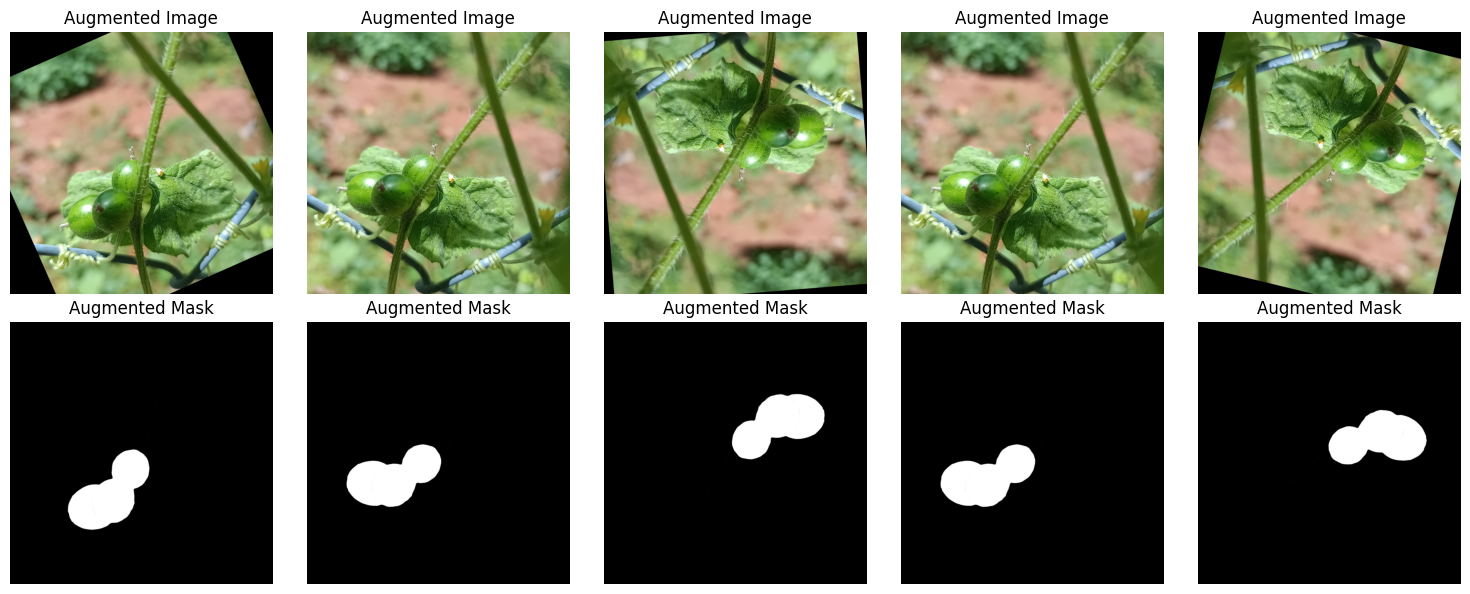

In [5]:
# Augmentation VIsualisation
import matplotlib.pyplot as plt
import cv2
import os

# Read one sample
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

img_path = os.path.join(image_dir,images[i])
mask_path = os.path.join(mask_dir,masks[i])

image = cv2.imread(img_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(mask_path,0)

# Create Figure
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for i in range(5):

    # Apply augmentation
    augmented = transform(
        image=image,
        mask=mask
    )

    aug_image = augmented["image"]

    aug_mask = augmented["mask"]

    # Show augmented image
    axes[0,i].imshow(aug_image)

    axes[0,i].set_title(
        "Augmented Image"
    )

    axes[0,i].axis("off")

    # Show augmented mask
    axes[1,i].imshow(
        aug_mask,
        cmap='gray'
    )

    axes[1,i].set_title(
        "Augmented Mask"
    )

    axes[1,i].axis("off")

plt.tight_layout()

plt.show()

In [6]:
from torch.utils.data import Dataset
import cv2
import torch


class SegDataSet(Dataset):
    def __init__(self,image_dir,mask_dir,transform = None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.transform = transform
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
                            
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self,idx):
        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )
        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path,0)

        #Augmentation
        if self.transform:
            augmented = self.transform(
                image = image,
                mask = mask
            )
            image = augmented["image"]
            mask = augmented["mask"]
        
        #Resize
        image = cv2.resize(image,(256,256))
        mask = cv2.resize(mask,(256,256))

        #normalise
        image = image/255.0
        mask = mask/255.0

        #Convert To Tensor
        image = torch.tensor(image).float()
        mask = torch.tensor(mask).float()
        
        image = image.permute(2,0,1)
        return image,mask
        


In [7]:
#TEST
dataset = SegDataSet(image_dir,mask_dir, transform = transform)
image,mask = dataset[0]
print(image.shape)

torch.Size([3, 256, 256])


In [8]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size = 4,
    shuffle = True
)

#for im , ma in loader:
#    print(im)
#   print(ma)
#   break

In [9]:
#U-Net
import torch.nn as nn

class DoubleConv(nn.Module):
    
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding = 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),

        nn.Conv2d(out_channels,out_channels, 3, padding = 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

#Encoder
class Down(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self,x):
        return self.down(x)


#Decoder
class Up(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size = 2,
            stride = 2
        )
        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self,x1,x2):
        x1 = self.up(x1)
        x = torch.cat([x2,x1],dim = 1)
        return self.conv(x)

#Unet
class UNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(3,64)
        self.down1 = Down(64,128)
        self.down2 = Down(128,256)
        self.down3 = Down(256,512)
        self.up1 = Up(512,256)
        self.up2 = Up(256,128)
        self.up3 = Up(128,64)
        
        self.outc = nn.Conv2d(64,1,kernel_size = 1)

    def forward(self,x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4,x3)
        x = self.up2(x,x2)
        x = self.up3(x,x1)
        x = self.outc(x)
        return x





In [10]:
#Creating model and connceting to GPU
device = torch.device("cuda")
model = UNET().to(device)

In [11]:
#Loss Function For Single
#criterion = nn.BCEWithLogitsLoss()

#Combined Loss Function
import torch.nn.functional as F

def dice_loss(preds, masks, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = preds.view(-1)
    masks = masks.view(-1)
    intersection = (preds * masks).sum()
    return 1 - (2. * intersection + smooth) / (preds.sum() + masks.sum() + smooth)

def combined_loss(outputs, masks):
    bce = F.binary_cross_entropy_with_logits(outputs, masks)
    dl  = dice_loss(outputs, masks)
    return bce + dl


In [12]:
#Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [13]:
#Dont use this
#Training Loop
#epochs = 5
#for epoch in range(epochs):
#    epoch_loss = 0
#    for images, masks in loader:
#        images = images.to(device)
#        masks = masks.unsqueeze(1).to(device)
#        outputs = model(images)
  #      loss = combined_loss(outputs,masks)
#        optimizer.zero_grad()
#        loss.backward()
#        optimizer.step()
##        epoch_loss += loss.item()

 #   avg_loss = epoch_loss / len(loader)
#    print(f"Epoch : {epoch+1} - Loss : {avg_loss}")

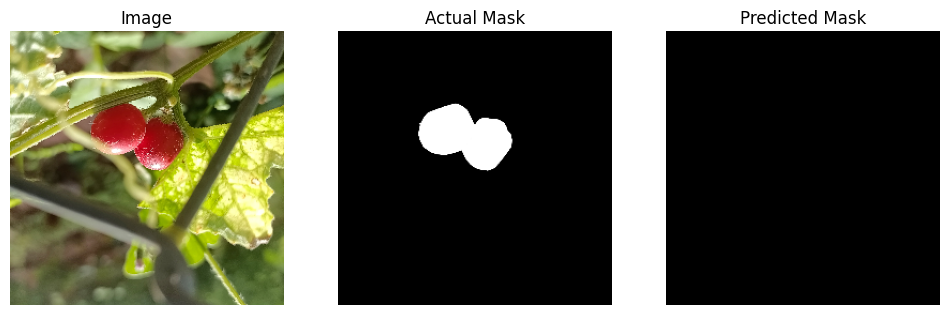

In [14]:
#Prediction Visualisation

import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    images, masks  = next(iter(loader))
    images = images.to(device)
    outputs = model(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

image = images[0]
mask = masks[0]
pred = preds[0]

image = image.permute(1,2,0)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask,cmap="gray")
plt.title("Actual Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred.squeeze(0),cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [15]:
#DICE Score

def dice_score(preds, masks):
    smooth = 1e-6
    preds = preds.view(-1)
    masks = masks.view(-1)
    intersection = (preds * masks).sum()
    dice = (2 * intersection + smooth) / (preds.sum() + masks.sum() + smooth)
    
    
    return dice.item()

In [16]:
#IOU Score
def iou_score(preds, masks):

    smooth = 1e-6
    preds = preds.view(-1)
    masks = masks.view(-1)

    intersection = (
        preds * masks
    ).sum()

    union = (
        preds.sum()
        +
        masks.sum()
        -
        intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.item()

In [17]:
#Test Train Split

from torch.utils.data import random_split

train_size = int(
    0.8 * len(dataset)
)
val_size = (
    len(dataset) - train_size
)
train_dataset,val_dataset = random_split(
    dataset,
    [train_size,val_size]
)

#Loaders For This
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [18]:
#Loss Arrays
train_losses = []
val_losses = []

#DICE Score And IOU Arrays
dice_scores = []
iou_scores = []

#Best Model
best_dice = 0.0

epochs = 60
for epoch in range(epochs):
    #Training Loop
    epoch_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.unsqueeze(1).to(device)
        outputs = model(images)
        loss = combined_loss(outputs,masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch : {epoch+1} -  Training Loss : {avg_loss}")
    train_losses.append(avg_loss)

    #Validation Loop
    model.eval()
    val_loss = 0
    dice = 0
    iou = 0
    with torch.no_grad():
        for images,masks in val_loader:  
            images = images.to(device)
            masks = masks.unsqueeze(1).to(device)
            outputs = model(images)
            #Loss 
            loss = combined_loss(outputs,masks)
            val_loss += loss.item()

            #DICE AND IOU
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            dice += dice_score(preds,masks)
            iou += iou_score(preds,masks)
    avg_val_loss = ( val_loss / len(val_loader) )
    val_losses.append(avg_val_loss)
    avg_dice = dice / len(val_loader)
    avg_iou = iou / len(val_loader)
    dice_scores.append(avg_dice)
    iou_scores.append(avg_iou)

    #Saving Best Model
    if(avg_dice > best_dice):
        best_dice = avg_dice
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Model saved! Best Dice: {best_dice:.4f}")
    model.train()    
    
    print(f"Epoch : {epoch+1} -  Val Loss : {avg_val_loss}")
    print(f"Epoch : {epoch+1} -  Dice Score : {avg_dice}")
    print(f"Epoch : {epoch+1} -  IOU Score : {avg_iou}")
    print("\n")
    
print(train_losses)
print(val_losses)

Epoch : 1 -  Training Loss : 1.239974558353424
Model saved! Best Dice: 0.0000
Epoch : 1 -  Val Loss : 0.9693967461585998
Epoch : 1 -  Dice Score : 1.2941442015246274e-10
Epoch : 1 -  IOU Score : 1.2941442015246274e-10


Epoch : 2 -  Training Loss : 1.158840860426426
Model saved! Best Dice: 0.6609
Epoch : 2 -  Val Loss : 0.9547916948795319
Epoch : 2 -  Dice Score : 0.660924705862999
Epoch : 2 -  IOU Score : 0.5042348891496659


Epoch : 3 -  Training Loss : 0.7674112513661384
Model saved! Best Dice: 0.7300
Epoch : 3 -  Val Loss : 0.6476172506809235
Epoch : 3 -  Dice Score : 0.7299840956926346
Epoch : 3 -  IOU Score : 0.5917740732431411


Epoch : 4 -  Training Loss : 0.5025248784571886
Epoch : 4 -  Val Loss : 0.562165093421936
Epoch : 4 -  Dice Score : 0.6816578388214112
Epoch : 4 -  IOU Score : 0.5312105596065522


Epoch : 5 -  Training Loss : 0.3635895822197199
Model saved! Best Dice: 0.8091
Epoch : 5 -  Val Loss : 0.3087235614657402
Epoch : 5 -  Dice Score : 0.8090765237808227
Epoch : 

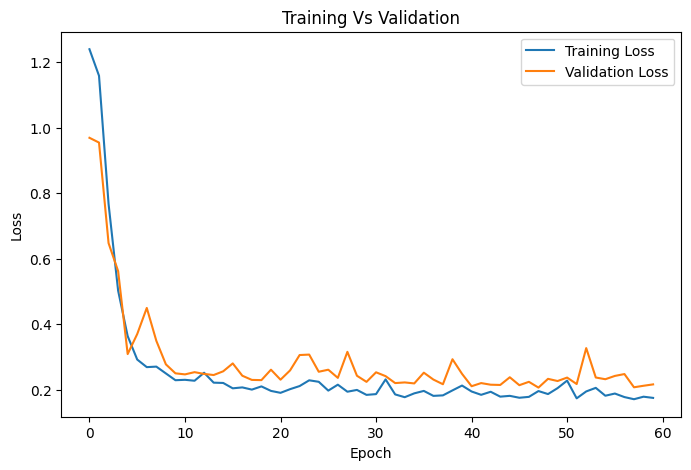

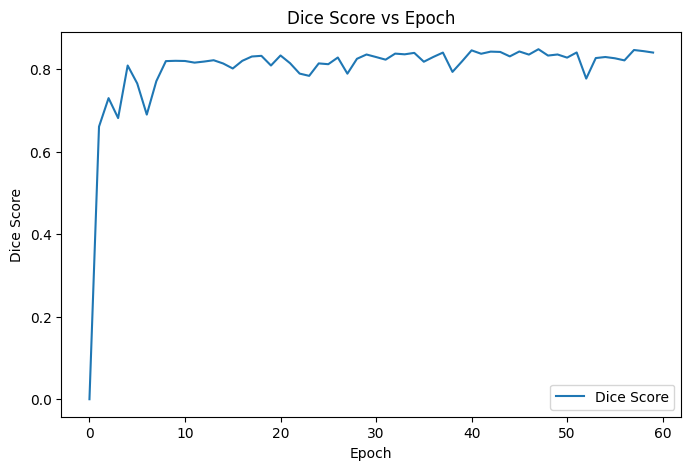

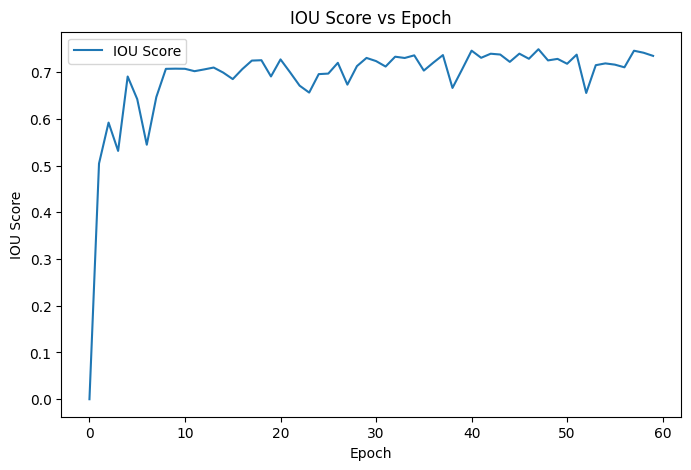

In [19]:
#Plotting The Curves

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(train_losses,label = "Training Loss")
plt.plot(val_losses,label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.title("Training Vs Validation")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_scores, label="Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize = (8,5))
plt.plot(iou_scores,label = "IOU Score")
plt.xlabel("Epoch")
plt.ylabel("IOU Score")
plt.title("IOU Score vs Epoch")
plt.legend()
plt.show()